# S01 — Notación y flujo de Machine Learning en seguros de automóviles

**Módulo 3 · Tema 1 · Subtemas 1, 2 y 3**

Este notebook acompaña la introducción conceptual a Machine Learning. Su objetivo es fijar la notación y el flujo de trabajo usando un caso sintético de seguros de automóviles.

No se desarrollan algoritmos específicos del Subtema 4. En particular, no se entrenan modelos de regresión, clasificación, árboles, boosting, K-Means ni PCA. El único cálculo predictivo es un **baseline** simple basado en la media del conjunto de entrenamiento.

## Requisitos de ejecución

Este notebook es autocontenido: genera todos los datos en memoria y no requiere
archivos externos.

**Entorno recomendado:**
- Python 3.11
- Jupyter Notebook, JupyterLab o VS Code con extensión Jupyter

**Instala las dependencias** (una sola vez, desde tu terminal):

```bash
pip install numpy pandas matplotlib scikit-learn jupyter
```

**Para ejecutar:** abre este archivo en Jupyter y selecciona *Ejecutar todo* (Run All).

## Objetivos de aprendizaje

Al finalizar, deberías poder identificar:

1. Qué son `X`, `y`, `y_pred`, `L(y, y_pred)` y el conjunto de datos `D`.
2. Cuándo un problema es supervisado y cuándo es no supervisado.
3. Por qué se separan datos en train/test antes de evaluar.
4. Cómo calcular métricas básicas para un baseline reproducible.
5. Cómo se ve un pipeline conceptual sin entrar todavía al algoritmo específico.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 20260618
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Base sintética de seguros de automóviles

La base representa pólizas simuladas. Cada fila corresponde a una póliza y cada columna describe una característica o una variable objetivo. La simulación usa una semilla fija para que los resultados sean reproducibles.

La variable `claim_frequency` se usa como ejemplo de objetivo supervisado de regresión. La variable `fraud_flag` se usa para ilustrar una etiqueta binaria de clasificación, sin entrenar todavía un clasificador.

In [4]:
def simulate_auto_insurance_portfolio(n_policies: int, seed: int = RANDOM_STATE) -> pd.DataFrame:
    """Genera una cartera sintética de seguros de autos para fines didácticos."""
    local_rng = np.random.default_rng(seed)

    region_values = np.array(["Norte", "Centro", "Sur", "Occidente"])
    vehicle_use_values = np.array(["Particular", "Trabajo", "Comercial"])
    coverage_values = np.array(["Básica", "Amplia", "Premium"])

    driver_age = np.clip(local_rng.normal(loc=42, scale=13, size=n_policies).round(), 18, 78).astype(int)
    vehicle_age = np.clip(local_rng.gamma(shape=2.3, scale=3.0, size=n_policies).round(), 0, 22).astype(int)
    annual_mileage = np.clip(local_rng.normal(loc=14_000, scale=4_500, size=n_policies), 2_000, 35_000).round().astype(int)
    region = local_rng.choice(region_values, size=n_policies, p=[0.26, 0.34, 0.20, 0.20])
    vehicle_use = local_rng.choice(vehicle_use_values, size=n_policies, p=[0.72, 0.18, 0.10])
    coverage = local_rng.choice(coverage_values, size=n_policies, p=[0.36, 0.48, 0.16])

    region_effect = pd.Series(region).map({"Norte": 0.06, "Centro": 0.02, "Sur": -0.03, "Occidente": 0.00}).to_numpy()#datos calibrados con la zona occidente
    # por eso esa zona tiene 0
    use_effect = pd.Series(vehicle_use).map({"Particular": 0.00, "Trabajo": 0.05, "Comercial": 0.11}).to_numpy()
    age_effect = np.where(driver_age < 25, 0.08, np.where(driver_age > 65, 0.04, 0.00))
    vehicle_effect = 0.008 * vehicle_age
    mileage_effect = 0.000006 * (annual_mileage - 12_000)

    claim_probability = np.clip(0.12 + region_effect + use_effect + age_effect + vehicle_effect + mileage_effect, 0.02, 0.72)
    # Binomial(3, p/3) da media = p y restringe el recuento a {0, 1, 2, 3} siniestros/año
    claim_count = local_rng.binomial(n=3, p=claim_probability / 3).astype(int)
    claim_frequency = claim_count.astype(float)

    claim_severity = np.where(
        claim_count > 0,
        local_rng.lognormal(mean=9.1, sigma=0.55, size=n_policies) * claim_count,  # exp(9.1) ≈ 8,955 MXN por siniestro
        0.0,
    )

    fraud_probability = np.clip(
        0.015
        + 0.012 * (vehicle_use == "Comercial")
        + 0.010 * (claim_severity > np.quantile(claim_severity, 0.90))
        + 0.006 * (driver_age < 25),
        0.005,
        0.12,
    )
    fraud_flag = local_rng.binomial(n=1, p=fraud_probability).astype(int)

    portfolio_profile = np.select(
        [
            (driver_age < 30) & (annual_mileage > 16_000),
            (vehicle_use == "Comercial") | (annual_mileage > 20_000),
            (driver_age > 58) & (coverage != "Básica"),
        ],
        ["Jóvenes alta exposición", "Uso intensivo", "Conductores senior"],
        default="Perfil estándar",
    )

    data = pd.DataFrame(
        {
            "policy_id": np.arange(1, n_policies + 1),
            "driver_age": driver_age,
            "vehicle_age": vehicle_age,
            "region": region,
            "vehicle_use": vehicle_use,
            "coverage": coverage,
            "annual_mileage": annual_mileage,
            "claim_count": claim_count,
            "claim_frequency": claim_frequency,
            "claim_severity": claim_severity.round(2),
            "fraud_flag": fraud_flag,
            "portfolio_profile": portfolio_profile,
        }
    )
    return data


portfolio = simulate_auto_insurance_portfolio(n_policies=10_000)

print(f"Filas: {portfolio.shape[0]:,}")
print(f"Columnas: {portfolio.shape[1]:,}")
display(portfolio.head())

Filas: 10,000
Columnas: 12


,policy_id,driver_age,vehicle_age,region,vehicle_use,coverage,annual_mileage,claim_count,claim_frequency,claim_severity,fraud_flag,portfolio_profile
0,1,34,4,Centro,Trabajo,Amplia,13028,0,0.0,0.0,0,Perfil estándar
1,2,60,6,Occidente,Particular,Básica,9326,0,0.0,0.0,0,Perfil estándar
2,3,51,5,Norte,Comercial,Básica,15086,0,0.0,0.0,1,Uso intensivo
3,4,46,7,Centro,Particular,Amplia,21719,0,0.0,0.0,0,Uso intensivo
4,5,18,7,Occidente,Trabajo,Amplia,5089,0,0.0,0.0,0,Perfil estándar


## 2. Exploración mínima de la cartera

Antes de formular `X` y `y`, revisamos si las variables simuladas tienen magnitudes razonables. Esta revisión no entrena ningún modelo; sólo ayuda a entender la estructura del conjunto de datos.

In [5]:
summary_columns = ["driver_age", "vehicle_age", "annual_mileage", "claim_count", "claim_frequency", "claim_severity"]
summary_table = portfolio[summary_columns].describe().T.round(2)
display(summary_table)

categorical_summary = {
    "region": portfolio["region"].value_counts(normalize=True).round(3),
    "vehicle_use": portfolio["vehicle_use"].value_counts(normalize=True).round(3),
    "coverage": portfolio["coverage"].value_counts(normalize=True).round(3),
    "portfolio_profile": portfolio["portfolio_profile"].value_counts(normalize=True).round(3),
}

for variable_name, distribution in categorical_summary.items():
    print(f"\nDistribución de {variable_name}:")
    display(distribution.to_frame("proporción"))

,count,mean,std,min,25%,50%,75%,max
driver_age,10000.0,42.39,12.74,18.0,34.00,42.0,51.00,78.00
vehicle_age,10000.0,6.88,4.43,0.0,4.00,6.0,9.00,22.00
annual_mileage,10000.0,13947.07,4485.40,2000.0,10910.75,13913.0,16915.25,32148.00
claim_count,10000.0,0.23,0.46,0.0,0.00,0.0,0.00,3.00
claim_frequency,10000.0,0.23,0.46,0.0,0.00,0.0,0.00,3.00
claim_severity,10000.0,2333.82,5528.79,0.0,0.00,0.0,0.00,77243.27



Distribución de region:


,proporción
region,
Centro,0.344
Norte,0.262
Sur,0.198
Occidente,0.197



Distribución de vehicle_use:


,proporción
vehicle_use,
Particular,0.722
Trabajo,0.178
Comercial,0.100



Distribución de coverage:


,proporción
coverage,
Amplia,0.475
Básica,0.361
Premium,0.163



Distribución de portfolio_profile:


,proporción
portfolio_profile,
Perfil estándar,0.726
Uso intensivo,0.166
Conductores senior,0.057
Jóvenes alta exposición,0.052


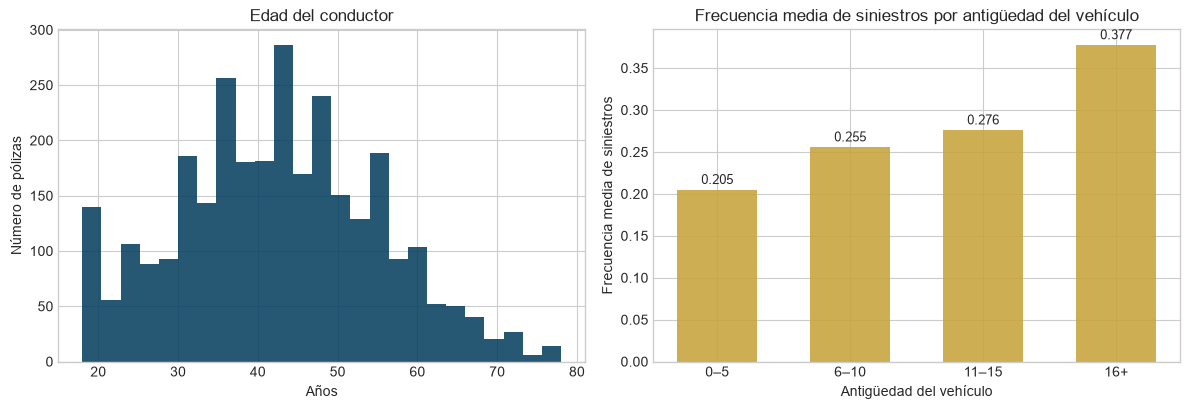

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(portfolio["driver_age"], bins=25, color="#003B5C", alpha=0.85)
axes[0].set_title("Edad del conductor")
axes[0].set_xlabel("Años")
axes[0].set_ylabel("Número de pólizas")

# Bar chart: frecuencia media de siniestros por intervalo de antigüedad del vehículo
age_bins = [0, 5, 10, 15, 22]
age_labels = ["0–5", "6–10", "11–15", "16+"]
vehicle_age_group = pd.cut(
    portfolio["vehicle_age"], bins=age_bins, labels=age_labels, right=True, include_lowest=True
)
mean_freq_by_age = portfolio.groupby(vehicle_age_group, observed=True)["claim_frequency"].mean()

bars = axes[1].bar(
    mean_freq_by_age.index.astype(str),
    mean_freq_by_age.values,
    color="#C8A33A",
    alpha=0.88,
    width=0.6,
)
for bar, value in zip(bars, mean_freq_by_age.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.004,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
axes[1].set_title("Frecuencia media de siniestros por antigüedad del vehículo")
axes[1].set_xlabel("Antigüedad del vehículo")
axes[1].set_ylabel("Frecuencia media de siniestros")

plt.tight_layout()
plt.show()

## 3. De una base de datos a la notación de Machine Learning

En aprendizaje supervisado trabajamos con un conjunto de entrenamiento:

$$D = \{(x_1, y_1), \ldots, (x_n, y_n)\}.$$

- `x_i` es el vector de características de la póliza `i`.
- `y_i` es la etiqueta o variable objetivo observada.
- `X` es la matriz con las características de muchas pólizas.
- `y` es el vector con la variable objetivo.

En este notebook usaremos `claim_frequency` como objetivo de regresión supervisada.

In [5]:
feature_columns = [
    "driver_age",
    "vehicle_age",
    "annual_mileage",
    "region",
    "vehicle_use",
    "coverage",
]
target_regression = "claim_frequency"
target_classification = "fraud_flag"

X = portfolio[feature_columns].copy()
y = portfolio[target_regression].copy()

print("X: matriz de características")
display(X.head())

print("y: variable objetivo para regresión supervisada")
display(y.head().to_frame(target_regression))

print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")

X: matriz de características


,driver_age,vehicle_age,annual_mileage,region,vehicle_use,coverage
0,34,13,12757,Sur,Comercial,Premium
1,60,8,20153,Norte,Trabajo,Básica
2,51,6,19635,Centro,Trabajo,Amplia
3,46,8,10161,Norte,Particular,Premium
4,18,9,20471,Norte,Particular,Amplia


y: variable objetivo para regresión supervisada


,claim_frequency
0,1.0
1,1.0
2,0.0
3,0.0
4,1.0


Dimensión de X: (3000, 6)
Dimensión de y: (3000,)


## 4. Aprendizaje supervisado: baseline de frecuencia

La pregunta actuarial es:

> ¿Cuál será la frecuencia anual de siniestros de una póliza dadas sus características?

Como existe una variable objetivo observada (`claim_frequency`), el problema es supervisado.

Para no adelantar los algoritmos del Subtema 4, usamos un **baseline** muy simple: predecir para todas las pólizas de test la frecuencia promedio observada en train. Este baseline no intenta capturar relaciones entre `X` e `y`; sólo sirve como referencia mínima.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

baseline_value = float(y_train.mean())
y_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_value, dtype=float)

mse = mean_squared_error(y_test, y_pred_baseline)
mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = float(np.sqrt(mse))

metrics_table = pd.DataFrame(
    {
        "metric": ["MAE", "MSE", "RMSE"],
        "value": [mae, mse, rmse],
        "interpretation": [
            "Error absoluto promedio del baseline",
            "Error cuadrático promedio del baseline",
            "Raíz del error cuadrático promedio",
        ],
    }
)

print(f"Promedio de frecuencia en train usado como baseline: {baseline_value:.4f}")
display(metrics_table.round(4))

Promedio de frecuencia en train usado como baseline: 0.2383


,metric,value,interpretation
0,MAE,0.3847,Error absoluto promedio del baseline
1,MSE,0.2395,Error cuadrático promedio del baseline
2,RMSE,0.4894,Raíz del error cuadrático promedio


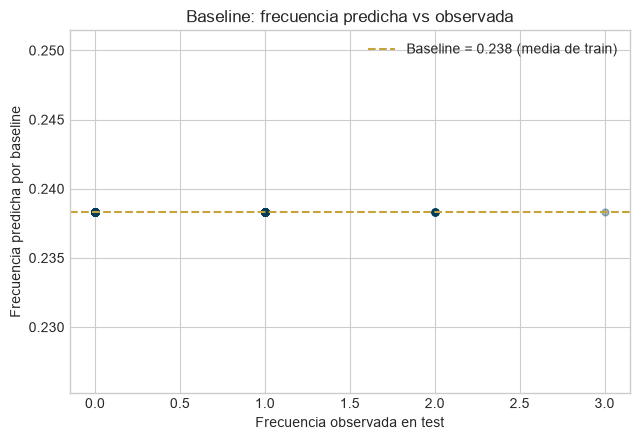

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(y_test, y_pred_baseline, alpha=0.35, s=24, color="#003B5C")
ax.axhline(baseline_value, color="#C8A33A", linestyle="--",
           label=f"Baseline = {baseline_value:.3f} (media de train)")
ax.set_title("Baseline: frecuencia predicha vs observada")
ax.set_xlabel("Frecuencia observada en test")
ax.set_ylabel("Frecuencia predicha por baseline")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Clasificación supervisada: etiqueta binaria sin entrenar clasificador

Otra pregunta de negocio podría ser:

> ¿Una reclamación tiene señales de fraude?

Aquí `fraud_flag` es una etiqueta binaria: `0` para no fraude y `1` para fraude. Este notebook sólo identifica la estructura del problema; el clasificador se estudiará después.

In [8]:
classification_target = portfolio[target_classification]
fraud_distribution = classification_target.value_counts(normalize=True).rename(index={0: "No fraude", 1: "Fraude"})
fraud_table = fraud_distribution.mul(100).round(2).to_frame("porcentaje")

display(fraud_table)
print("Este es un problema supervisado porque la etiqueta fraud_flag está observada en la base sintética.")

,porcentaje
fraud_flag,
No fraude,98.23
Fraude,1.77


Este es un problema supervisado porque la etiqueta fraud_flag está observada en la base sintética.


## 6. Aprendizaje no supervisado: estructura sin `y`

En aprendizaje no supervisado no se define una variable objetivo. La pregunta cambia:

> ¿Qué perfiles de pólizas aparecen en la cartera si observo sólo sus características?

Para mantener el alcance introductorio, no aplicamos K-Means, PCA ni otro algoritmo. Sólo visualizamos características y usamos un perfil sintético predefinido para discutir la idea de segmentación.

In [9]:
X_unsupervised = portfolio[["driver_age", "vehicle_age", "annual_mileage", "region", "vehicle_use", "coverage"]].copy()

print("X_unsupervised no contiene claim_frequency ni fraud_flag.")
display(X_unsupervised.head())

profile_counts = portfolio["portfolio_profile"].value_counts().to_frame("n_policies")
profile_counts["share"] = (profile_counts["n_policies"] / len(portfolio)).round(3)
display(profile_counts)

X_unsupervised no contiene claim_frequency ni fraud_flag.


,driver_age,vehicle_age,annual_mileage,region,vehicle_use,coverage
0,34,13,12757,Sur,Comercial,Premium
1,60,8,20153,Norte,Trabajo,Básica
2,51,6,19635,Centro,Trabajo,Amplia
3,46,8,10161,Norte,Particular,Premium
4,18,9,20471,Norte,Particular,Amplia


,n_policies,share
portfolio_profile,,
Perfil estándar,2168,0.723
Uso intensivo,497,0.166
Conductores senior,179,0.060
Jóvenes alta exposición,156,0.052


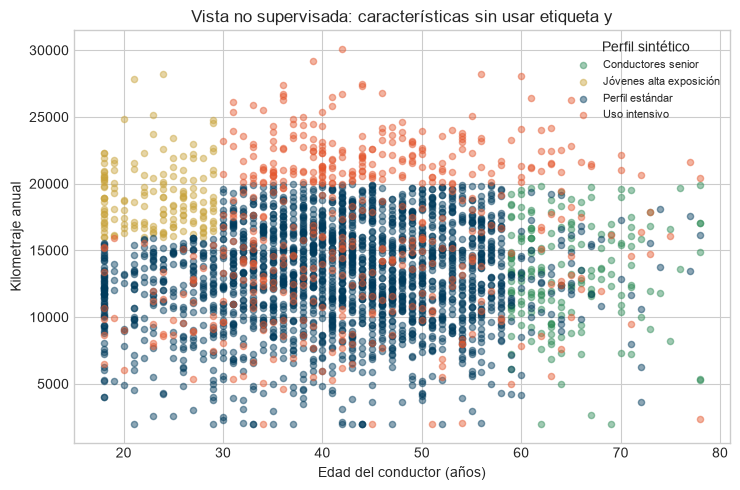

In [10]:
profile_colors = {
    "Perfil estándar": "#003B5C",
    "Jóvenes alta exposición": "#C8A33A",
    "Uso intensivo": "#E4572E",
    "Conductores senior": "#2E8B57",
}

fig, ax = plt.subplots(figsize=(7.5, 5.0))
for profile_name, profile_data in portfolio.groupby("portfolio_profile"):
    ax.scatter(
        profile_data["driver_age"],
        profile_data["annual_mileage"],
        s=20,
        alpha=0.45,
        color=profile_colors[profile_name],
        label=profile_name,
    )

ax.set_title("Vista no supervisada: características sin usar etiqueta y")
ax.set_xlabel("Edad del conductor (años)")
ax.set_ylabel("Kilometraje anual")
ax.legend(title="Perfil sintético", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Train/test y prevención de leakage

Separar train y test ayuda a estimar si una solución generaliza a pólizas no vistas. Una regla práctica:

- **Train:** datos para aprender parámetros o reglas.
- **Test:** datos reservados para evaluación final.

Incluso transformaciones simples, como calcular una media para estandarizar, deben aprenderse con train y luego aplicarse a test. Si se usa test para definir transformaciones, aparece **data leakage**. En este ejemplo las diferencias son pequeñas porque el split es aleatorio y la base es grande; con datos de producción o splits temporales la discrepancia puede ser mayor y más relevante.

In [11]:
split_summary = pd.DataFrame(
    {
        "set": ["train", "test"],
        "n_rows": [len(X_train), len(X_test)],
        "share": [len(X_train) / len(X), len(X_test) / len(X)],
    }
)

display(split_summary)

leakage_example = pd.DataFrame(
    {
        "quantity": ["Media de annual_mileage en train", "Media de annual_mileage en toda la base"],
        "value": [X_train["annual_mileage"].mean(), X["annual_mileage"].mean()],
    }
).round(2)

display(leakage_example)
print("La segunda media usa información de test; por eso no debe usarse para ajustar transformaciones evaluadas en test.")

,set,n_rows,share
0,train,2400,0.8
1,test,600,0.2


,quantity,value
0,Media de annual_mileage en train,13957.39
1,Media de annual_mileage en toda la base,14018.07


La segunda media usa información de test; por eso no debe usarse para ajustar transformaciones evaluadas en test.


## 8. Pipeline conceptual

Un pipeline organiza el flujo de trabajo, pero no define por sí mismo el algoritmo. En el Subtema 4 se estudiarán modelos concretos. Por ahora basta con distinguir las etapas.

In [12]:
pipeline_concept = pd.DataFrame(
    [
        (1, "Definir problema", "Elegir Y y la métrica de éxito"),
        (2, "Construir X e y", "Separar características y variable objetivo"),
        (3, "Dividir train/test", "Reservar datos para evaluación honesta"),
        (4, "Preprocesar", "Aprender transformaciones sólo con train"),
        (5, "Entrenar", "Ajustar un modelo específico; se estudia en el Subtema 4"),
        (6, "Evaluar", "Comparar y_test contra y_pred con métricas"),
        (7, "Documentar", "Registrar supuestos, datos, métricas y limitaciones"),
    ],
    columns=["step", "stage", "purpose"],
)

display(pipeline_concept)

,step,stage,purpose
0,1,Definir problema,Elegir Y y la métrica de éxito
1,2,Construir X e y,Separar características y variable objetivo
2,3,Dividir train/test,Reservar datos para evaluación honesta
3,4,Preprocesar,Aprender transformaciones sólo con train
4,5,Entrenar,Ajustar un modelo específico; se estudia en el...
5,6,Evaluar,Comparar y_test contra y_pred con métricas
6,7,Documentar,"Registrar supuestos, datos, métricas y limitac..."


## 9. Validaciones internas del notebook

Las siguientes pruebas simples garantizan que el notebook es reproducible, que las dimensiones son coherentes y que no se usaron datos externos.

In [13]:
expected_columns = {
    "policy_id",
    "driver_age",
    "vehicle_age",
    "region",
    "vehicle_use",
    "coverage",
    "annual_mileage",
    "claim_count",
    "claim_frequency",
    "claim_severity",
    "fraud_flag",
    "portfolio_profile",
}

assert set(portfolio.columns) == expected_columns
assert portfolio.shape == (3_000, 12)
assert X.shape == (3_000, 6)
assert y.shape == (3_000,)
assert len(X_train) == 2_400
assert len(X_test) == 600
assert len(y_pred_baseline) == len(y_test)
assert np.isfinite(metrics_table["value"]).all()
assert portfolio["claim_frequency"].ge(0).all()
assert portfolio["fraud_flag"].isin([0, 1]).all()
assert target_regression not in X_unsupervised.columns
assert target_classification not in X_unsupervised.columns

# Reproducibilidad: la misma semilla debe producir la misma base
portfolio_check = simulate_auto_insurance_portfolio(n_policies=3_000, seed=RANDOM_STATE)
assert portfolio.equals(portfolio_check), "La función no es reproducible con la misma semilla."

print("Validaciones internas completadas correctamente.")

Validaciones internas completadas correctamente.


## Cierre

Este notebook no pretende construir el mejor modelo, sino formular correctamente el problema:

- `X` contiene características de las pólizas.
- `y` contiene la respuesta observada cuando el problema es supervisado.
- `y_pred` representa una predicción.
- `L(y, y_pred)` mide discrepancia entre observación y predicción.
- El split train/test protege la evaluación contra conclusiones demasiado optimistas.
- El aprendizaje no supervisado cambia la pregunta: busca estructura en `X` sin una etiqueta `y`.

Con esta base, los siguientes materiales pueden introducir algoritmos concretos sin perder la notación ni el flujo de trabajo.

In [14]:
# =============================================================================
# EXPORTACIÓN OPCIONAL — cambia EXPORT_DATA = True para guardar el CSV en disco
# El notebook funciona correctamente con EXPORT_DATA = False
# =============================================================================

EXPORT_DATA = False

if EXPORT_DATA:
    export_path = Path.cwd() / "auto_insurance_intro_ml.csv"
    portfolio.to_csv(export_path, index=False)
    print(f"CSV exportado en: {export_path}")
else:
    print("Exportación desactivada. Cambia EXPORT_DATA = True para guardar el CSV.")

Exportación desactivada. Cambia EXPORT_DATA = True para guardar el CSV.
